# 🚀 Enterprise Data Profiler

This notebook orchestrates an **automated, deep-dive data profiling engine** on datasets using the high-performance `GlobalProfiler` suite.

Unlike traditional profiling packages, this engine employs **memory-bounded sampling** and mathematical bounds heuristics, bypassing traditional JVM/memory bottlenecks to profile dirty, large-scale, and heterogeneous datasets seamlessly.

### 🌐 Cross-Dataset Orchestration & Relationship Mapping:
1. **Global Master Dashboard**: Full executive summary of quality scores, schema shapes, data-type compositions, and warnings.
2. **Relational ERD Discovery**: Automatically detects Primary/Foreign Key relations and generates standard **Mermaid ER Diagrams** for database reconstruction.
3. **Exploratory Data Analysis (EDA)**: Interactive data-density landscapes, missingness heatmaps, and categorical class balances.
4. **Heuristic Action Plan**: Generates targeted, warning-coded cleanup guidelines (corrupt values, mixed-type anomalies, multicollinearity).

---

### 📜 Global Profiler Configuration Schema

Configure the dynamic parameters of the orchestrator to customize scanning boundaries and AI context privacy.

| Parameter | Type | Description | Default / Options | Example |
|:---|:---|:---|:---|:---|
| `directory` | `str`/`Path` | Target folder containing the source datasets. | Any valid path | `"Dataset"` |
| `file_type` | `str`/`None` | File format extension filter. Set to `None` for **automatic autodetection** of all supported formats! | `"csv"`, `"xlsx"`, `"parquet"`, `None` | `None` |
| `include_keywords` | `str`/`List` | Substring filter to selectively profile target files. Case-insensitive. | `[]` | `["olist"]` |
| `private` | `bool`/`Dict` | Dynamic PII privacy masking toggle. Can be a global boolean or a dictionary mapping dataset stems to booleans for selective privacy! | `True`, `False`, or Dict | `{"olist_customers_dataset": False}` |
| `export_md` | `str`/`bool` | Path to export LLM-optimized dense Markdown context. | File path or `False` to skip | `"ai_context.md"` |

### 📋 Blank Configuration Template

Copy this block and customize for your project:

```python
PROFILER_CONFIG = {
    # ── Core Pipeline Settings ──────────────────────────────────────
    "directory": "Dataset",
    "file_type": None,                    
    "include_keywords": [],                

    # ── Privacy & Export Settings ───────────────────────────────────
    "private": True,                       
    "export_md": "ai_context.md"           
}
```

---
## ⚙️ Step 1: Configuration & Import
Define your folder scanning parameters, keyword filters, and privacy settings using the GlobalProfiler ledger below.

In [1]:
# ──────────────────────────────────────────────
# Configuration Zone
# ──────────────────────────────────────────────

PROFILER_CONFIG = {
    # ── Core Pipeline Settings ──────────────────────────────────────
    "directory": "Dataset",
    "file_type": None,                     # Set to None for automatic format detection
    "include_keywords": ["olist", "product"],        

    # ── Privacy & Export Settings ───────────────────────────────────
    "private": True,                       # Enable/disable PII masking (True/False or Dict mapping)
    "export_md": "ai_context.md"           # Path to export optimized context for LLMs
}

---
## 🚀 Step 2: Global Profile Generation & Context Export
Run this cell to render the interactive Master Dashboard, execute individual file deep-dives, and automatically export the LLM-optimized dense Markdown context according to your configurations.

File Name,Rows,Cols,Duplicates,Quality,Missing %,Critical Alerts,Potential Savings
olist_closed_deals_dataset.csv,842,14,0,88%,28.0%,4,-212.1 KB
olist_customers_dataset.csv,"50,000",5,0,100%,0.0%,0,-2.4 MB
olist_geolocation_dataset.csv,"50,000",5,"21,054",70%,0.0%,2,-5.7 MB
olist_marketing_qualified_leads_dataset.csv,"8,000",4,0,98%,0.2%,0,-450.7 KB
olist_order_items_dataset.csv,"50,000",7,0,100%,0.0%,0,-389.9 KB
olist_order_payments_dataset.csv,"50,000",5,0,100%,0.0%,1,-3.1 MB
olist_order_reviews_dataset.csv,"50,000",7,0,91%,21.0%,2,-0.0 B
olist_orders_dataset.csv,"50,000",8,0,99%,0.6%,0,-2.7 MB
olist_products_dataset.csv,"32,951",9,0,99%,0.8%,1,-2.8 MB
olist_sellers_dataset.csv,"3,095",4,0,100%,0.0%,0,-149.0 KB

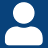
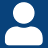
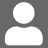


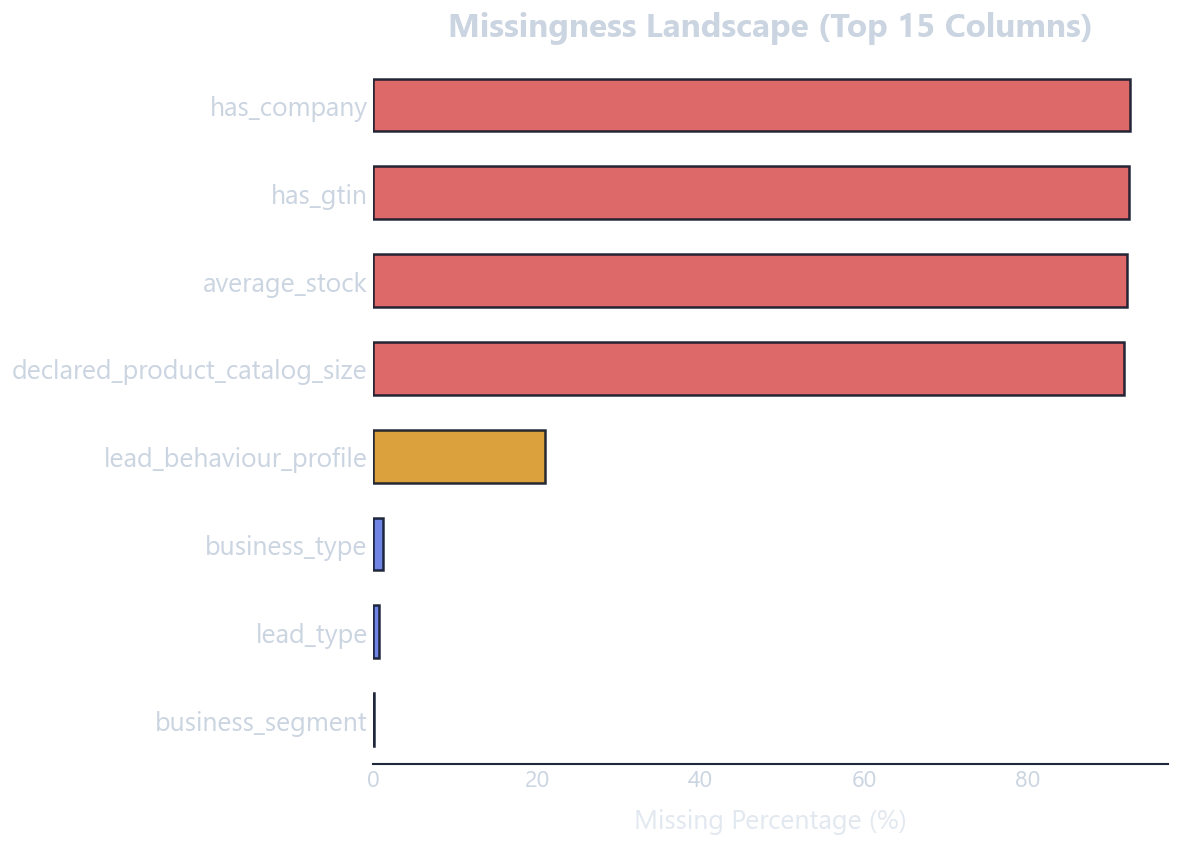
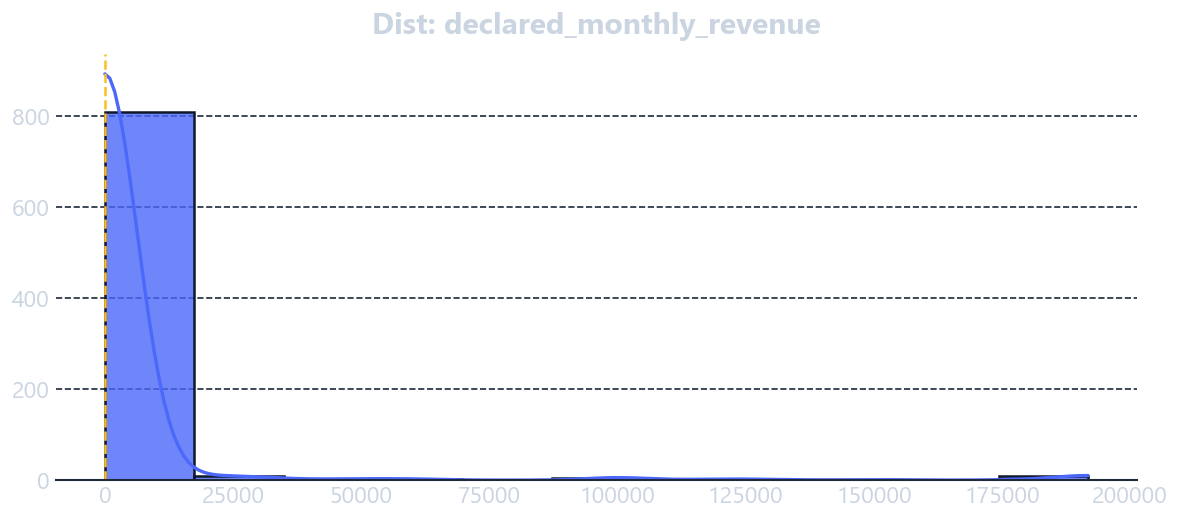
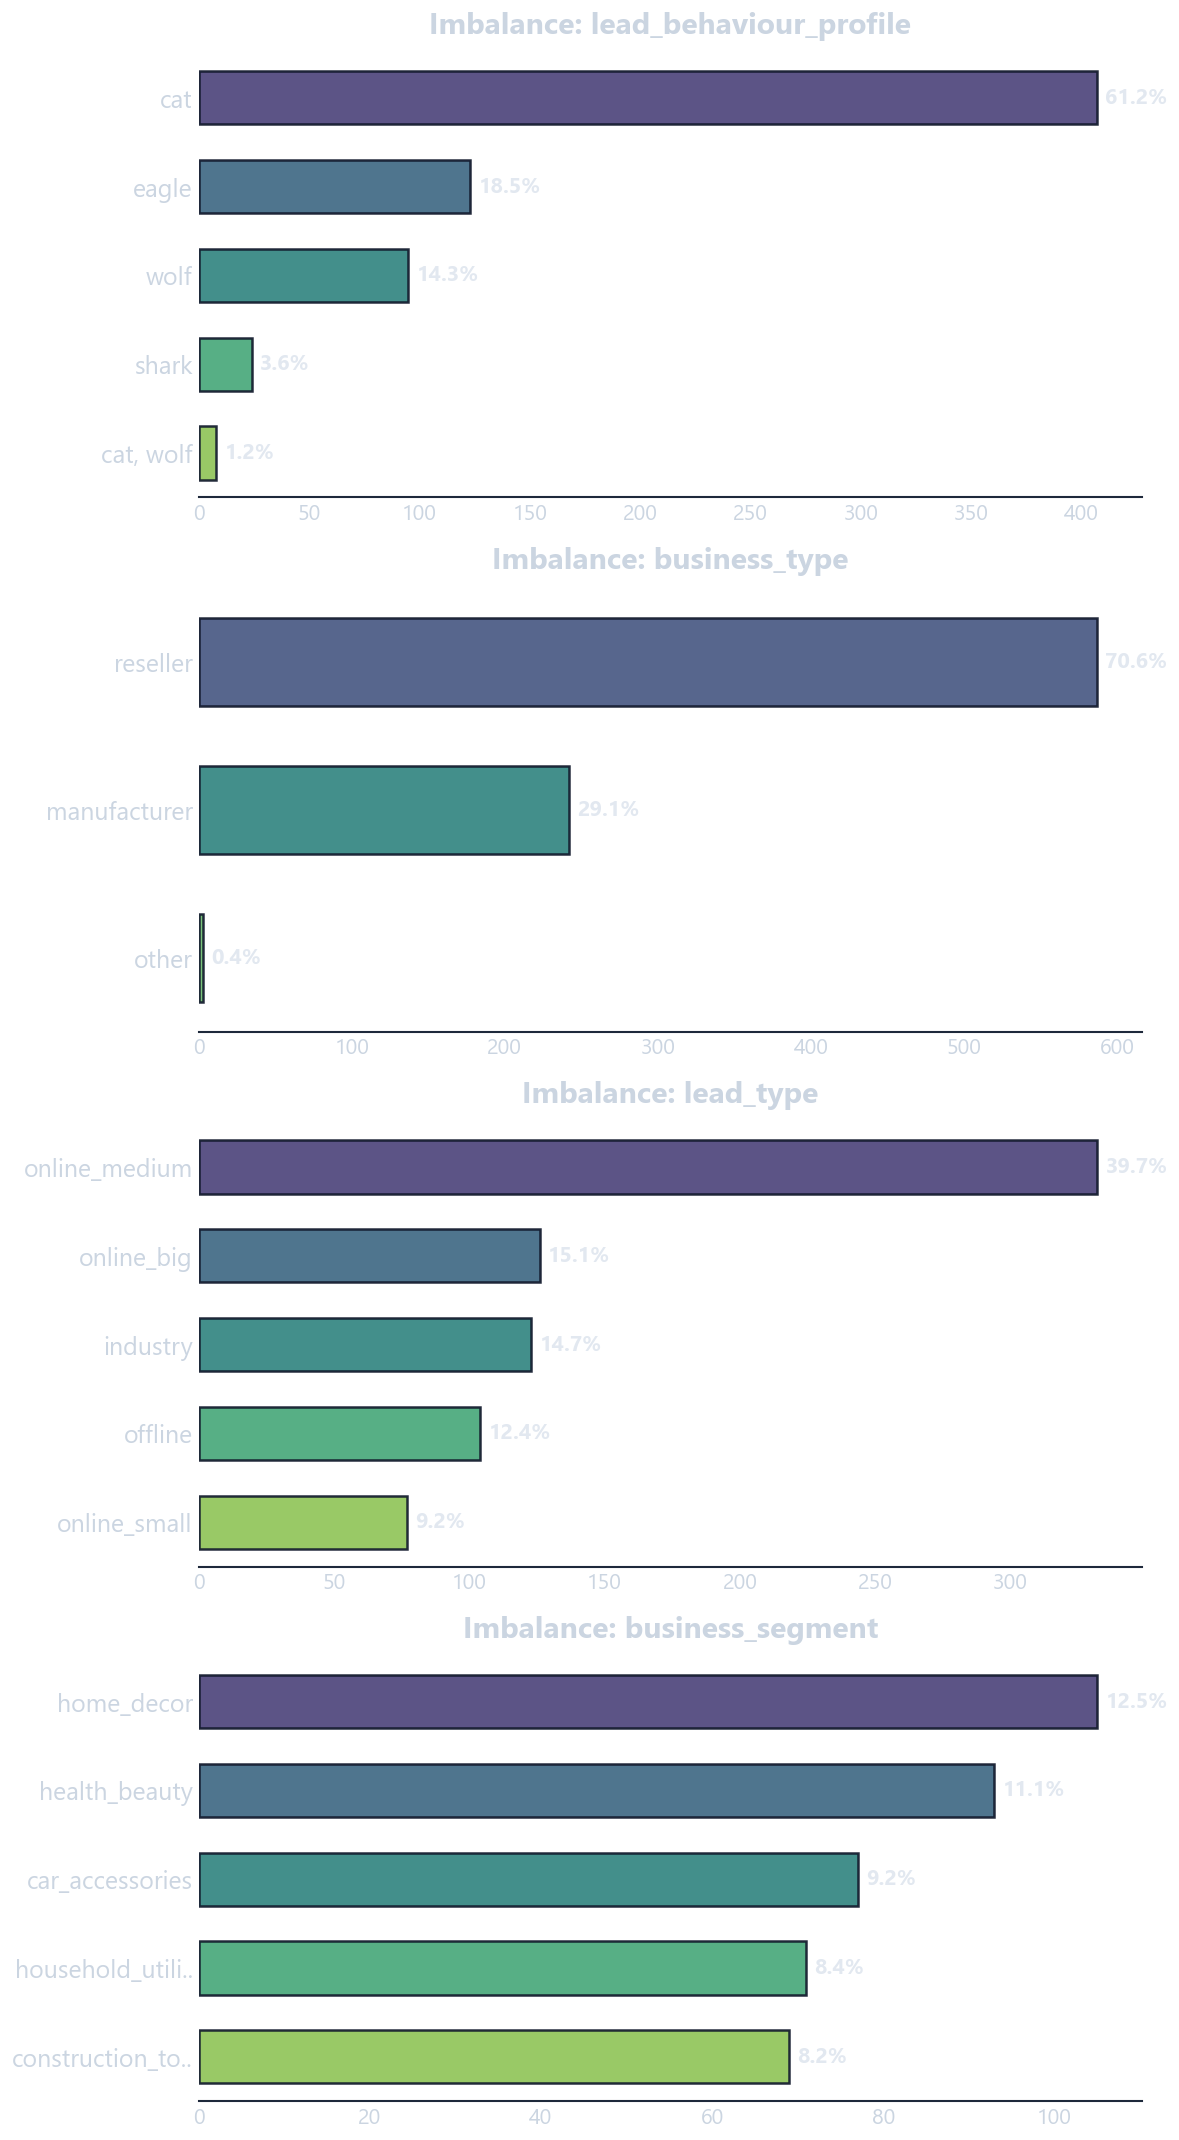
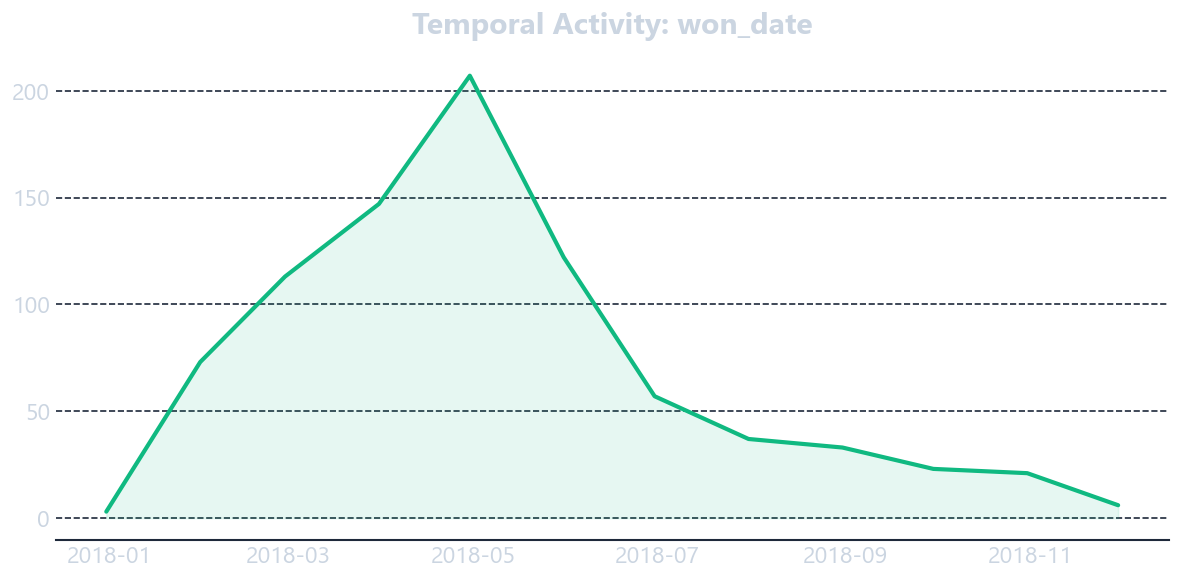


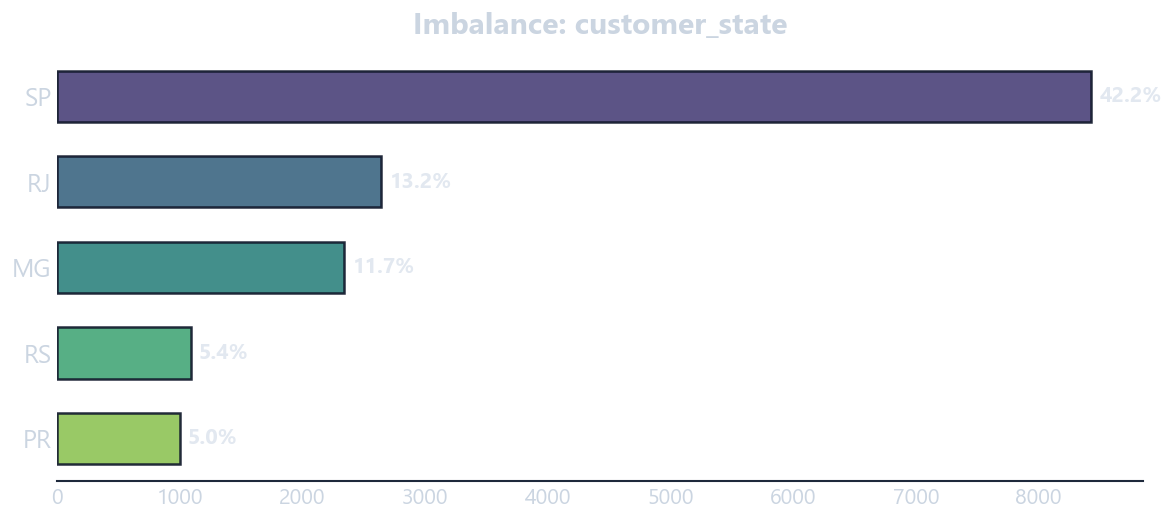


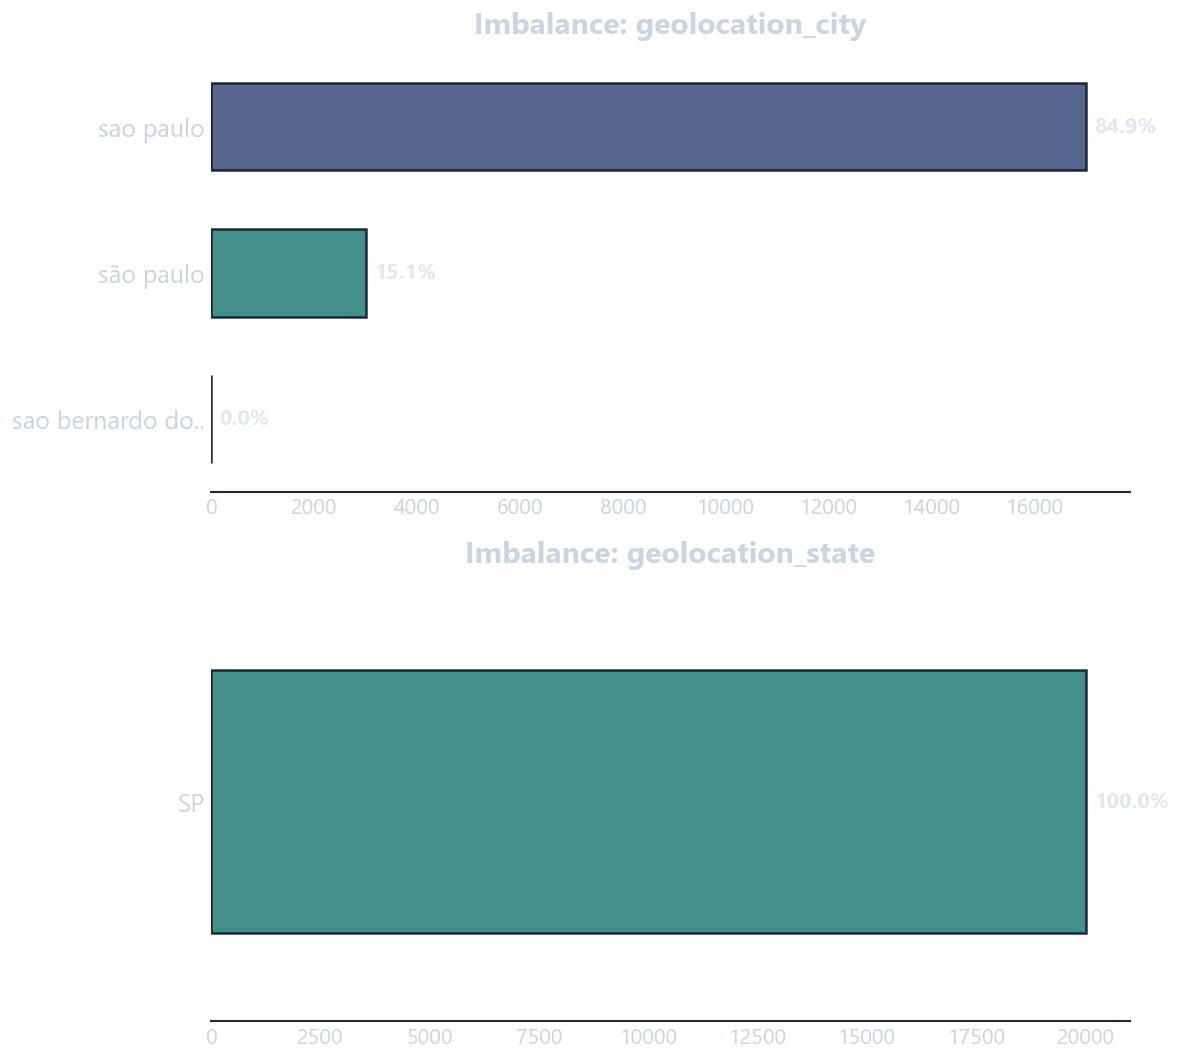


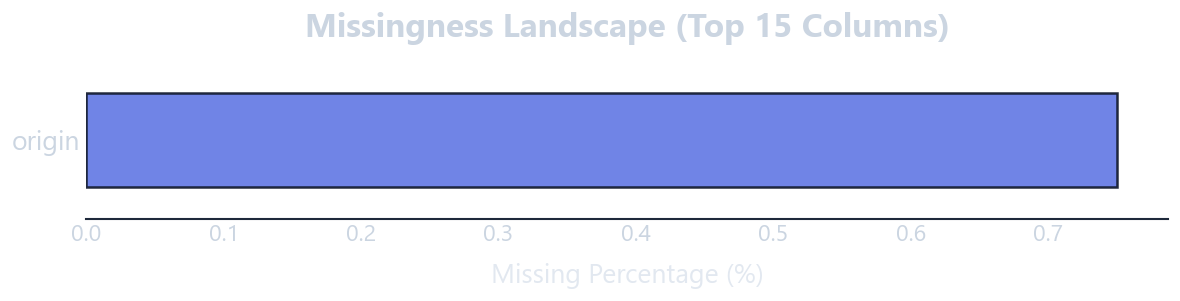
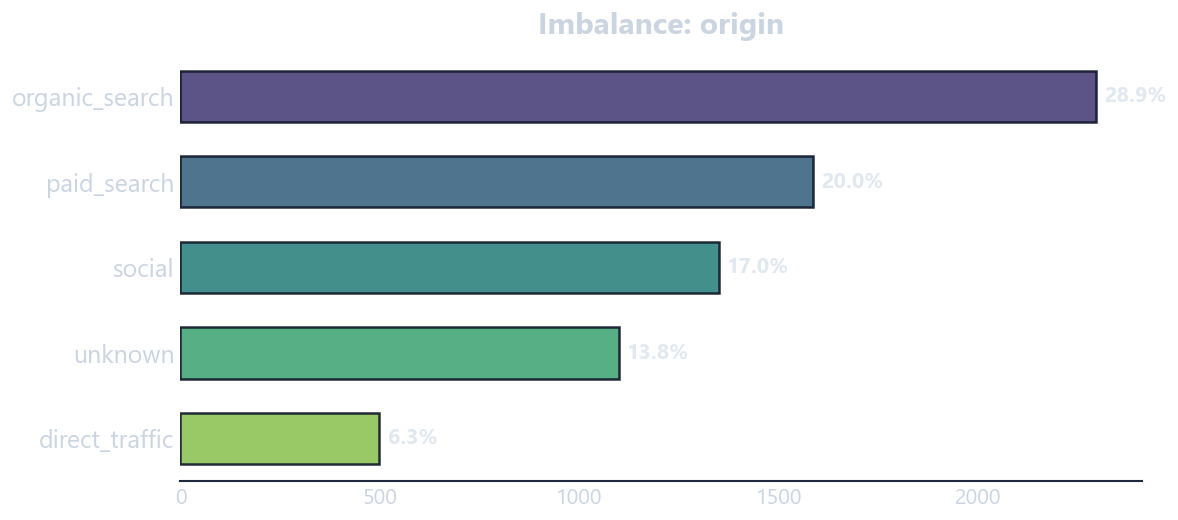
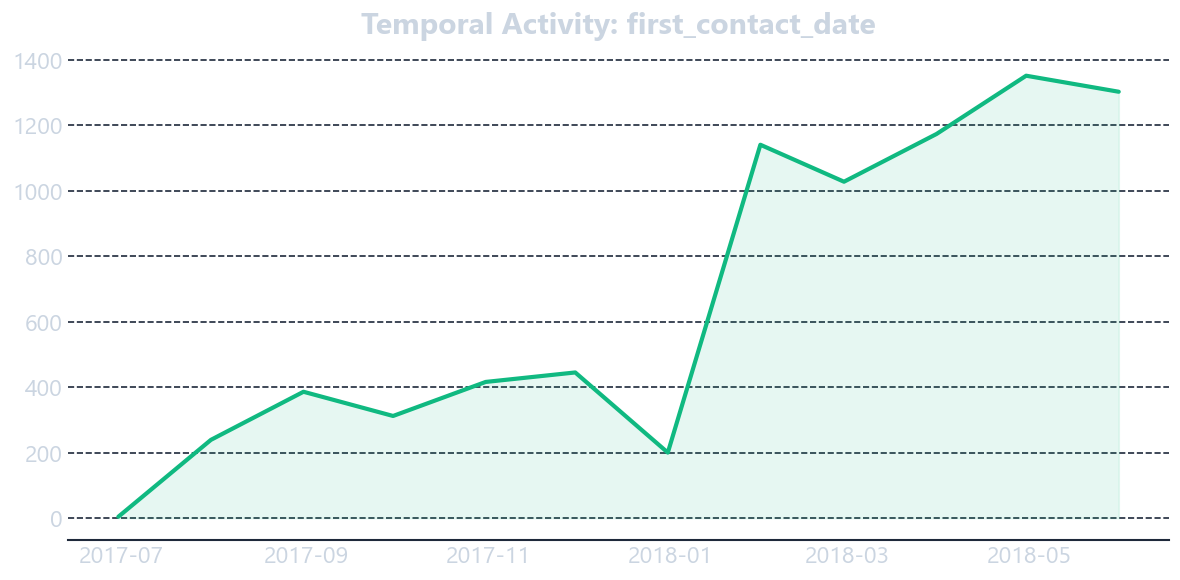


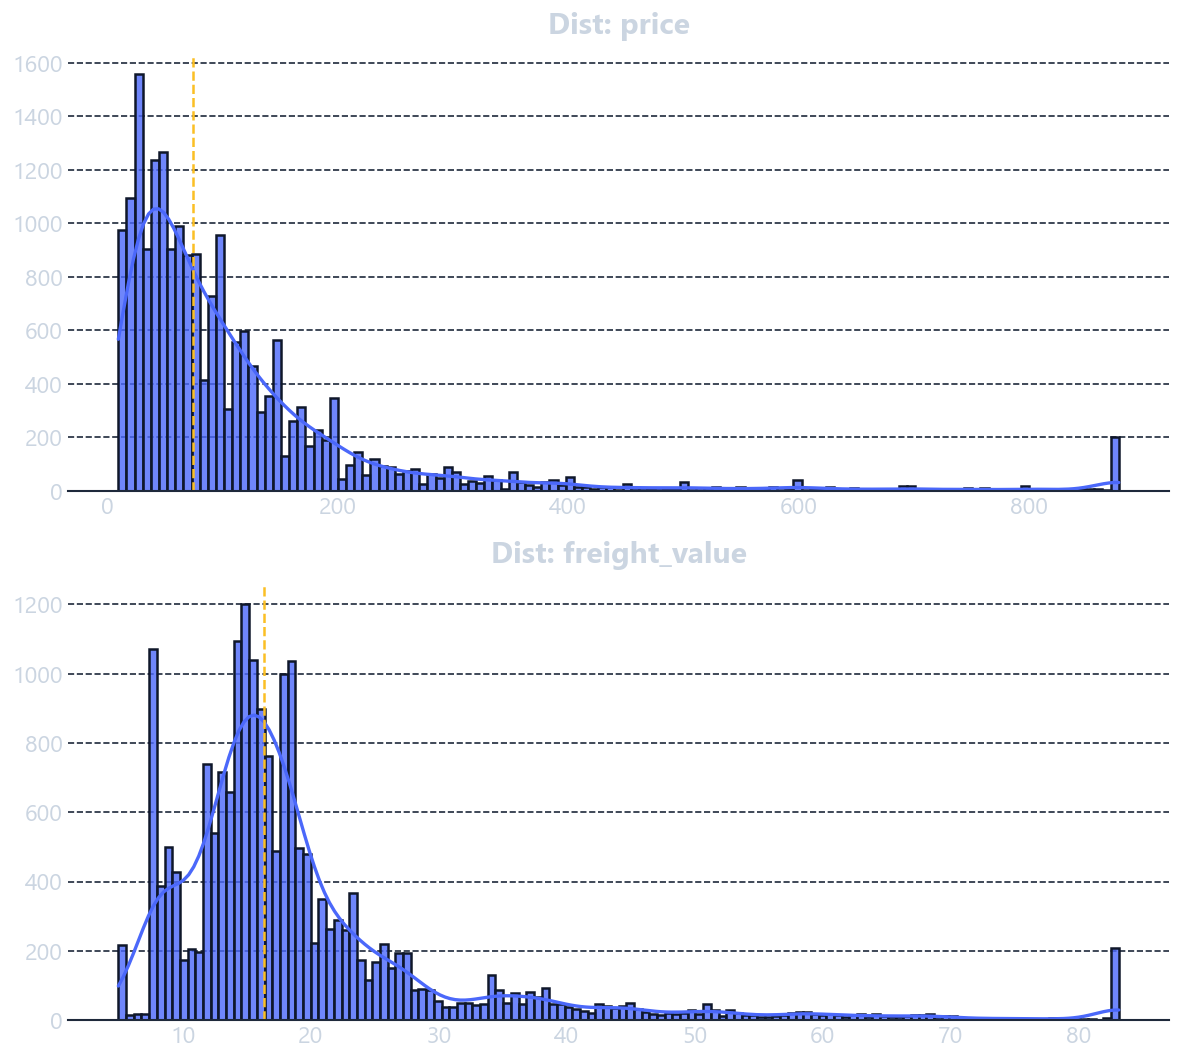
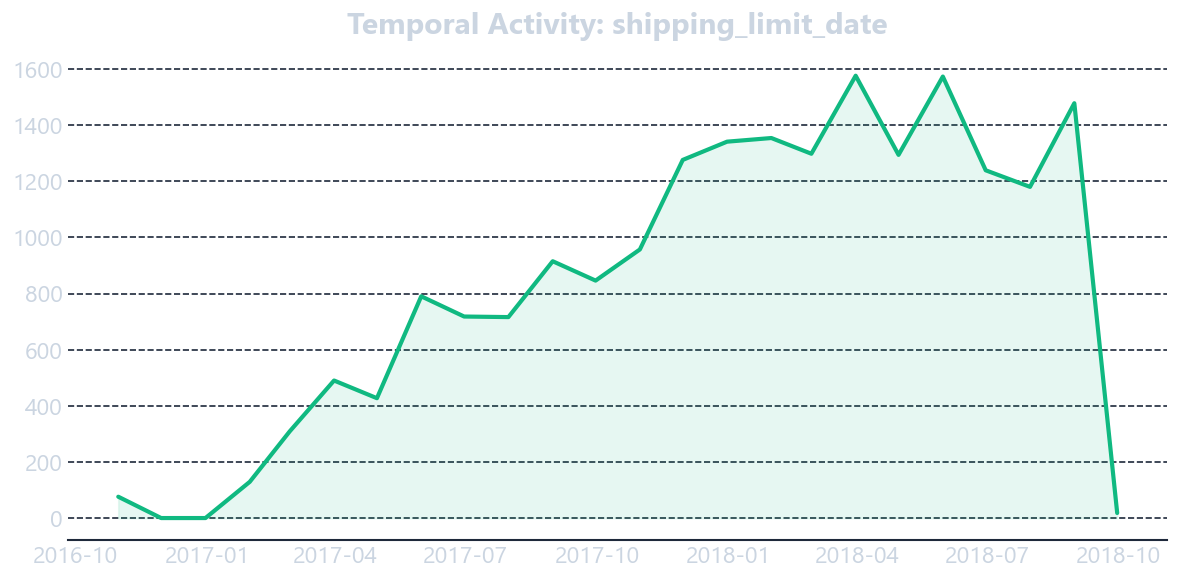


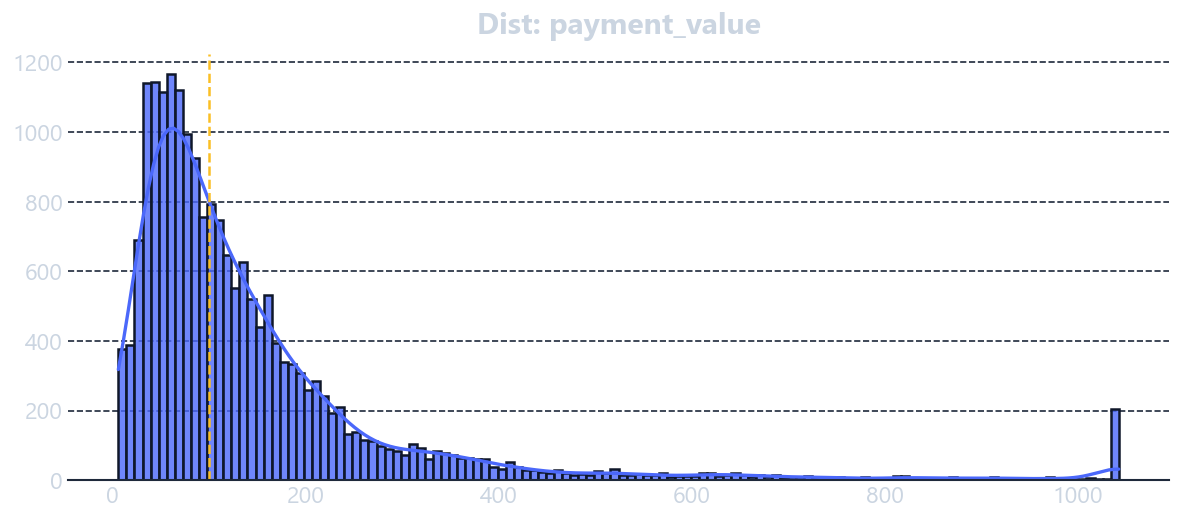
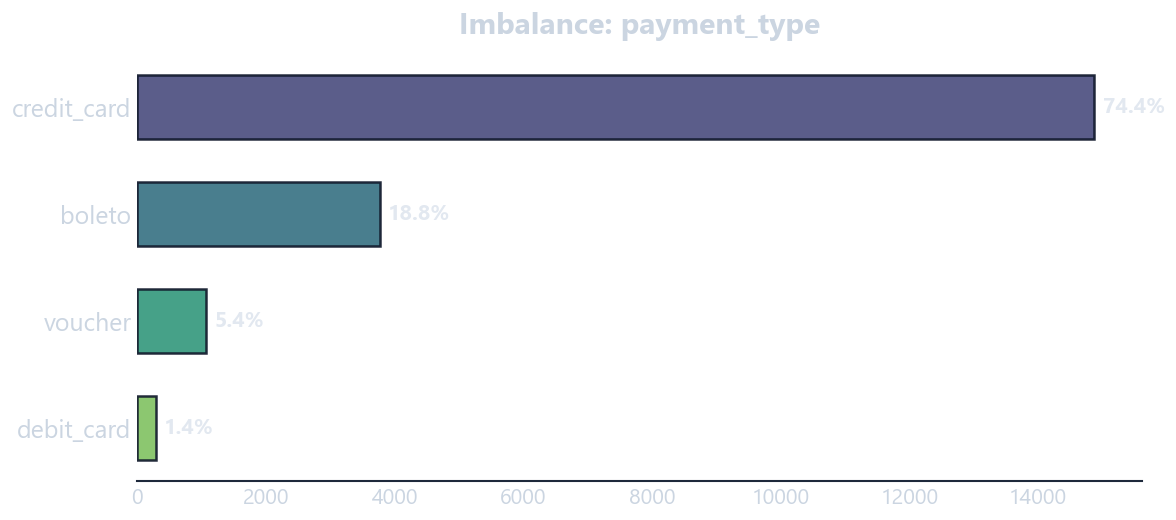


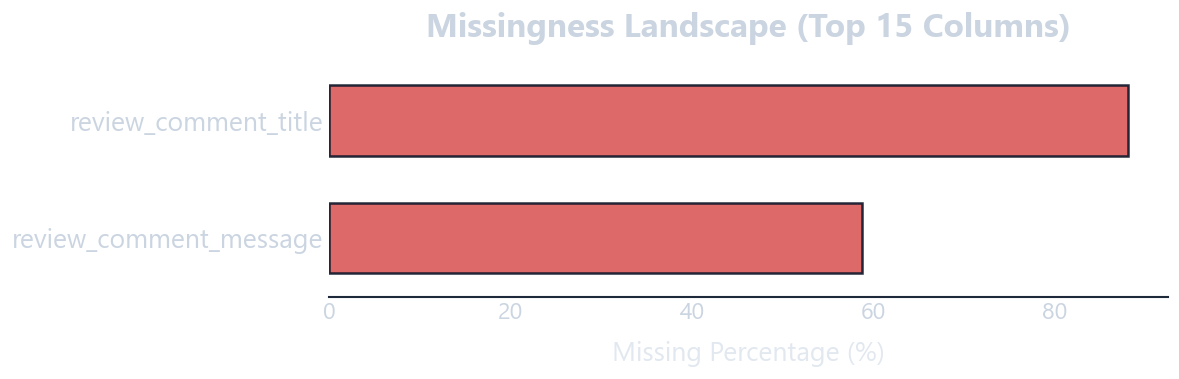
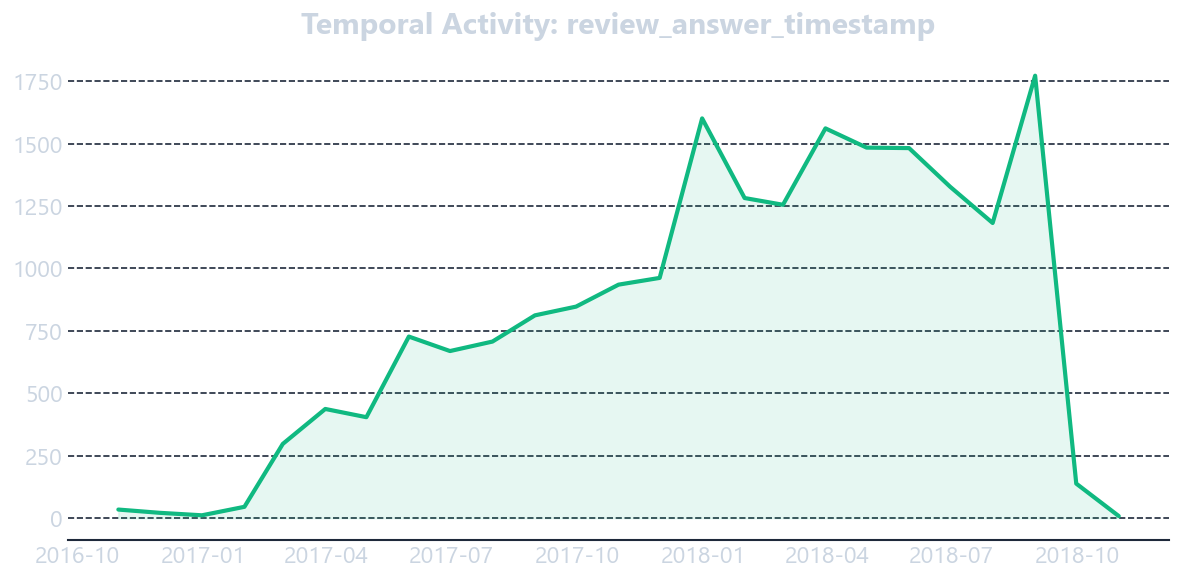


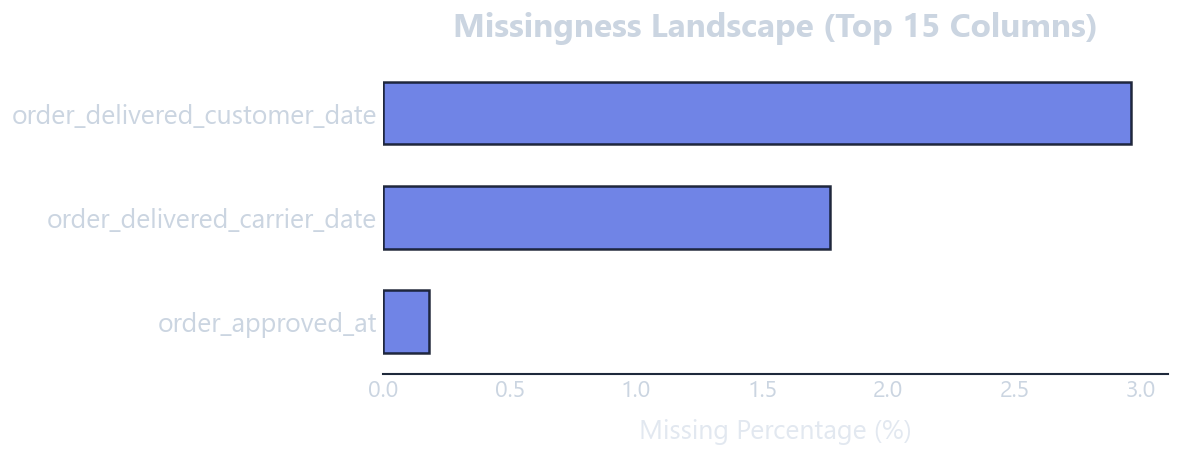
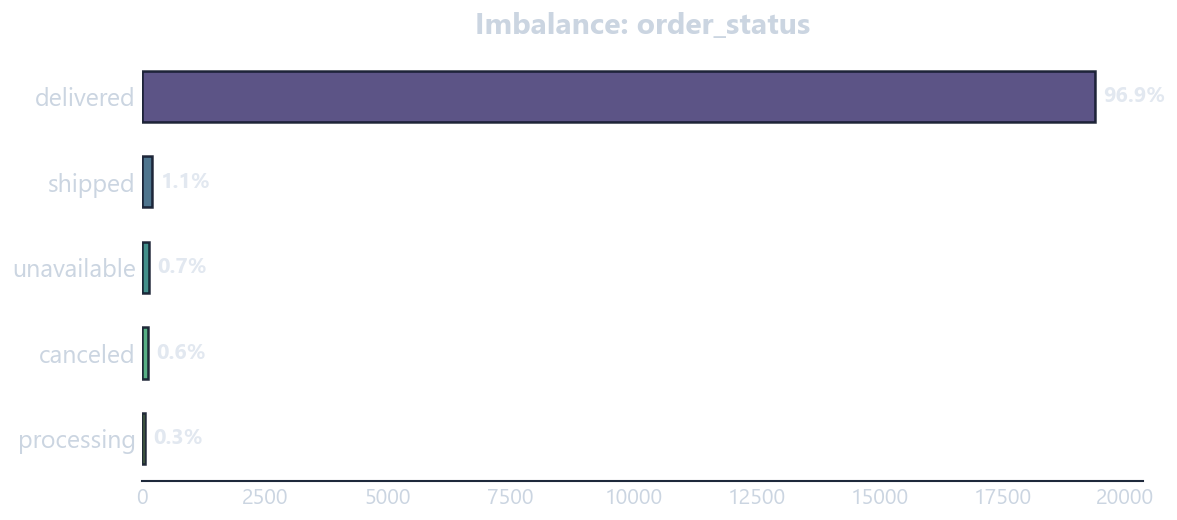
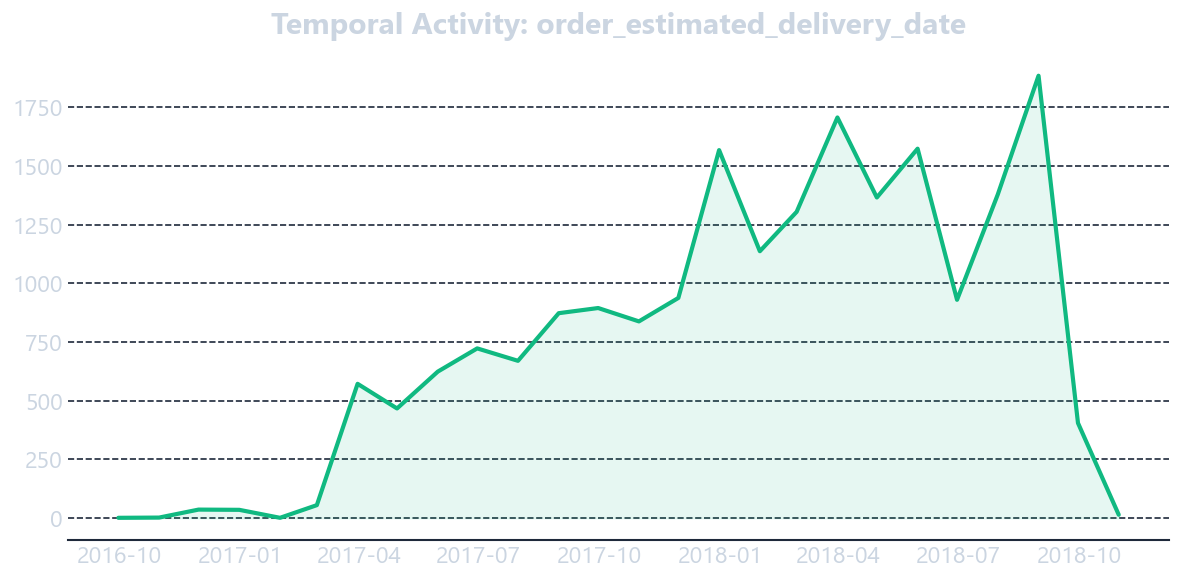


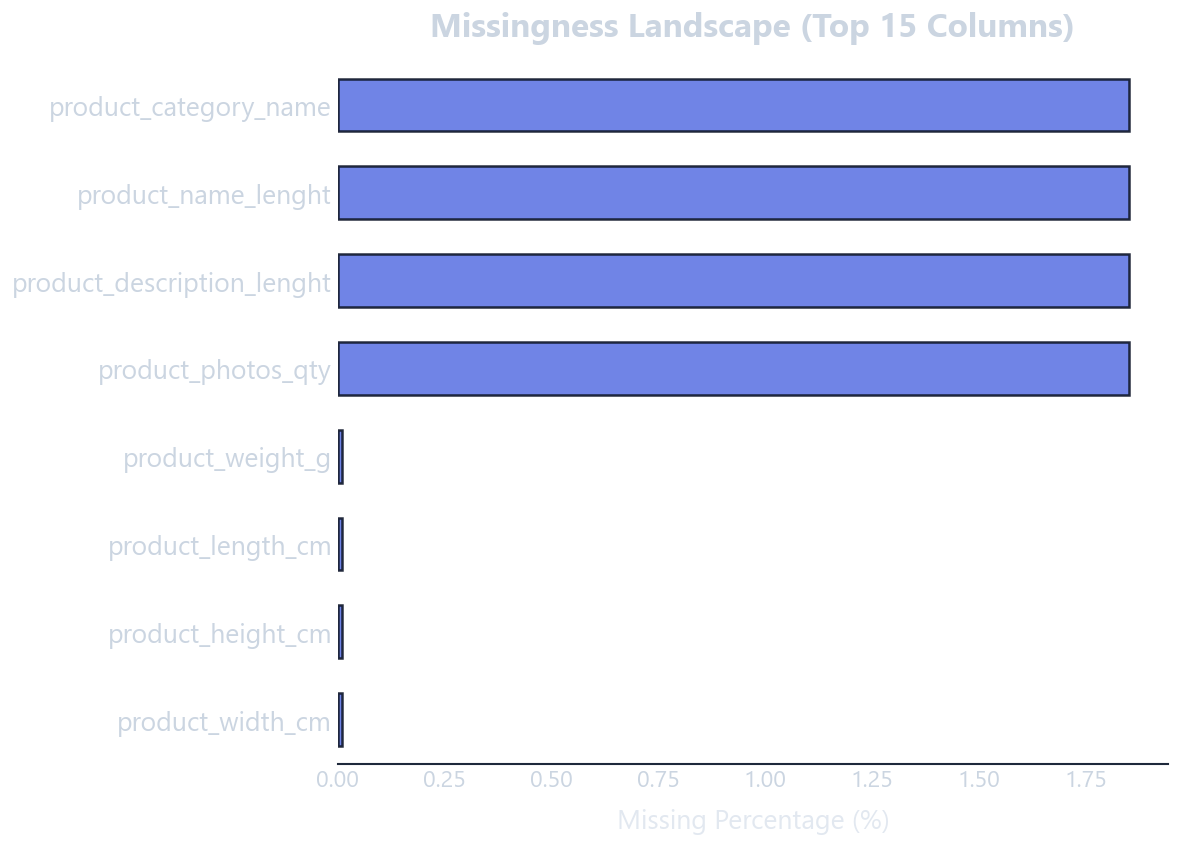
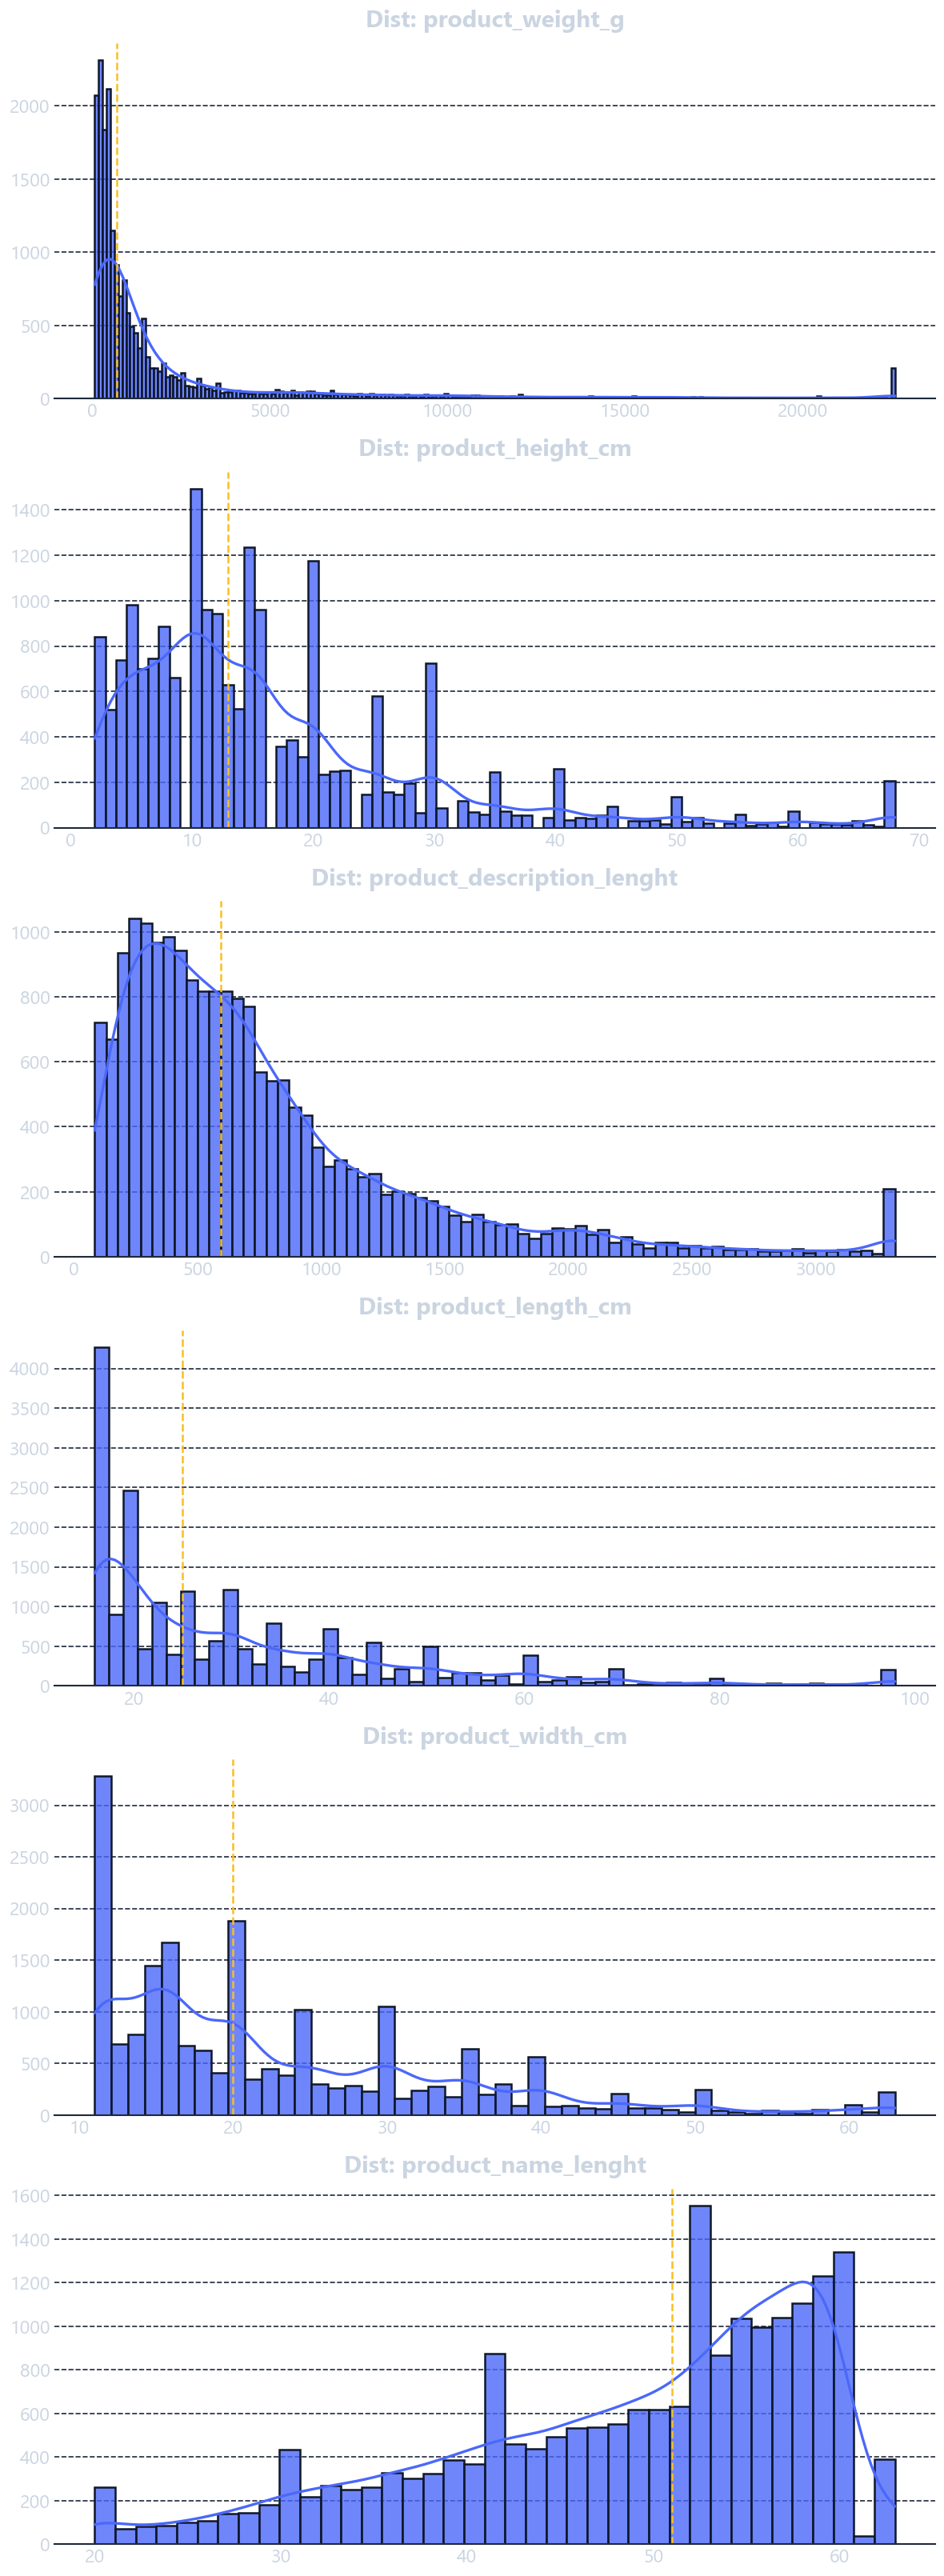


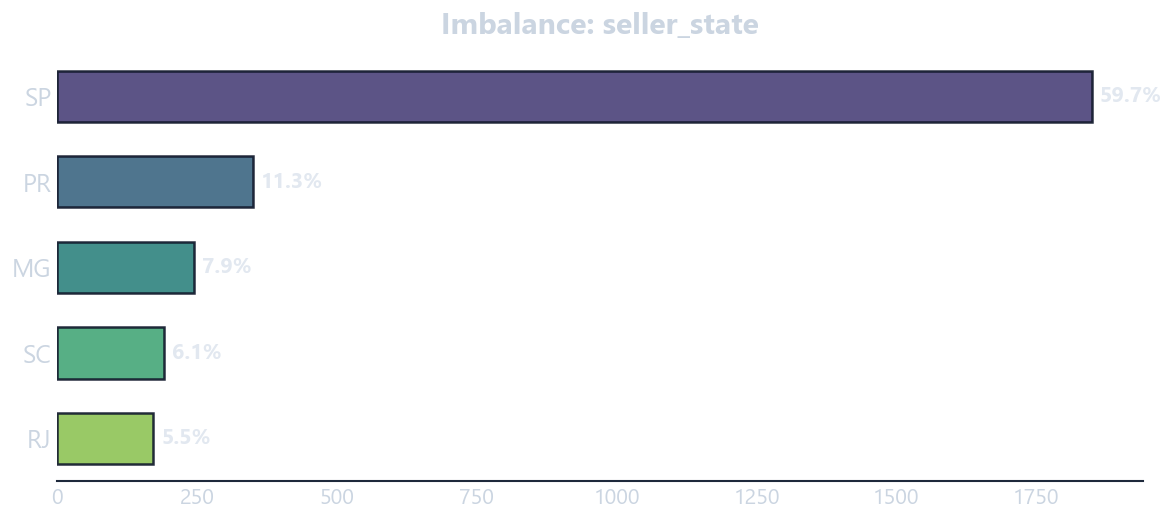

In [2]:
# ──────────────────────────────────────────────
# Profile all datasets & Export LLM Context
# ──────────────────────────────────────────────

from data_profiler_engine import GlobalProfiler

global_profiler = GlobalProfiler.from_directory(PROFILER_CONFIG)
global_profiler.profile_all()